# Exploratory Data Analysis and Feature Engineering

**IBM Applied Data Science Capstone**  
Repository owner: `phuonganhdt220391`

This notebook explores relationships among flight number, payload mass,
launch site, orbit and first-stage landing success. It also creates the
one-hot encoded feature table used by the machine-learning notebook.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path(".")
data = pd.read_csv(DATA_DIR / "dataset_part_2.csv")
print("Shape:", data.shape)
data.head()

Shape: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


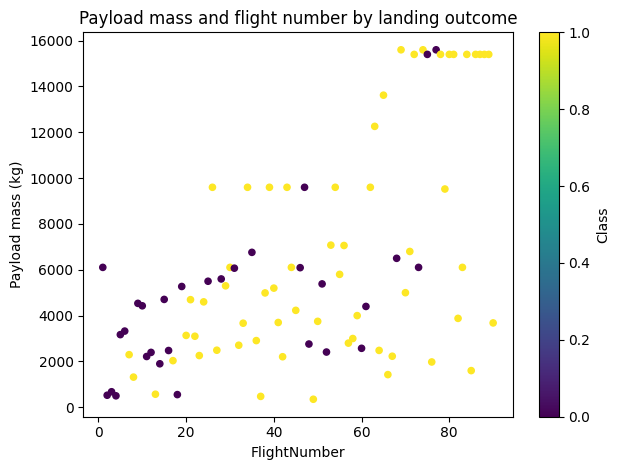

In [2]:
ax = data.plot.scatter(
    x="FlightNumber", y="PayloadMass", c="Class", colormap="viridis",
    title="Payload mass and flight number by landing outcome"
)
ax.set_ylabel("Payload mass (kg)")
plt.tight_layout()
plt.show()

In [3]:
site_summary = (
    data.groupby("LaunchSite")
        .agg(Launches=("Class", "size"), SuccessRate=("Class", "mean"),
             AveragePayload=("PayloadMass", "mean"))
        .sort_values("SuccessRate", ascending=False)
)
site_summary

,Launches,SuccessRate,AveragePayload
LaunchSite,,,
KSC LC 39A,22,0.772727,7606.450856
VAFB SLC 4E,13,0.769231,5919.461538
CCAFS SLC 40,55,0.600000,5548.207786


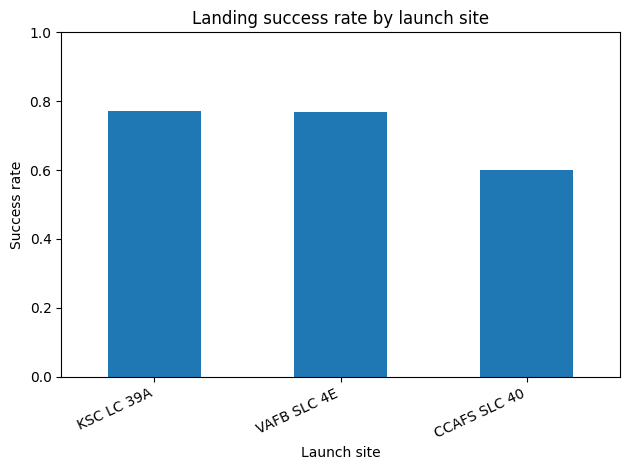

In [4]:
ax = site_summary["SuccessRate"].plot(
    kind="bar", title="Landing success rate by launch site"
)
ax.set_xlabel("Launch site")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [5]:
orbit_summary = (
    data.groupby("Orbit")
        .agg(Launches=("Class", "size"), SuccessRate=("Class", "mean"))
        .query("Launches >= 2")
        .sort_values(["SuccessRate", "Launches"], ascending=False)
)
orbit_summary

,Launches,SuccessRate
Orbit,,
SSO,5,1.000000
VLEO,14,0.857143
LEO,7,0.714286
PO,9,0.666667
MEO,3,0.666667
ISS,21,0.619048
GTO,27,0.518519


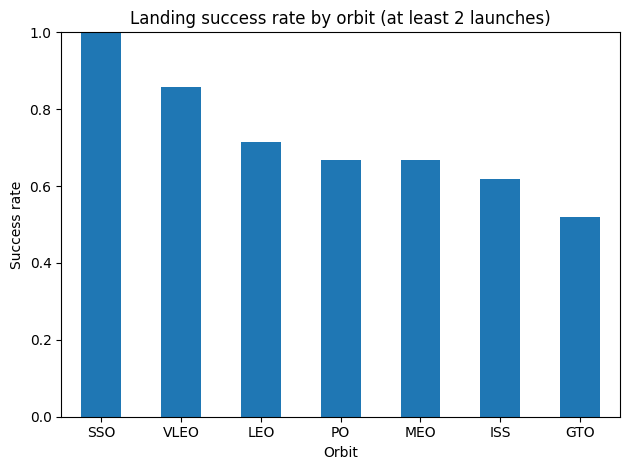

In [6]:
ax = orbit_summary["SuccessRate"].plot(
    kind="bar", title="Landing success rate by orbit (at least 2 launches)"
)
ax.set_xlabel("Orbit")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

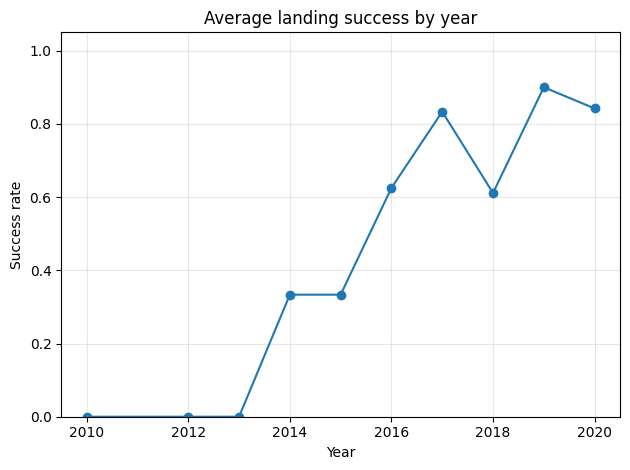

In [7]:
yearly = data.assign(Year=pd.to_datetime(data["Date"]).dt.year).groupby("Year")["Class"].mean()
ax = yearly.plot(marker="o", title="Average landing success by year")
ax.set_xlabel("Year")
ax.set_ylabel("Success rate")
ax.set_ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature engineering

Numeric and boolean predictors are retained. Orbit, launch site, landing pad
and booster serial are one-hot encoded. The target `Class` is deliberately
excluded from the feature table.

In [8]:
features = data[[
    "FlightNumber", "PayloadMass", "Orbit", "LaunchSite", "Flights",
    "GridFins", "Reused", "Legs", "LandingPad", "Block",
    "ReusedCount", "Serial"
]].copy()

features_one_hot = pd.get_dummies(
    features,
    columns=["Orbit", "LaunchSite", "LandingPad", "Serial"],
    dtype=float,
)
for col in ["GridFins", "Reused", "Legs"]:
    features_one_hot[col] = features_one_hot[col].astype(float)
features_one_hot = features_one_hot.astype(float)

features_one_hot.to_csv(DATA_DIR / "dataset_part_3.csv", index=False)
print("Feature matrix shape:", features_one_hot.shape)
features_one_hot.head()

Feature matrix shape: (90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Key observations

- Landing success generally improves for later flights and later years.
- Success rates vary across launch sites and orbit types.
- The engineered feature matrix is ready for classification modeling.